In [1]:
from datasets import load_dataset
dataset = load_dataset("usvsnsp/generation-semantic-filters")

Generating pile_duped_6.9b split:   0%|          | 0/5000000 [00:00<?, ? examples/s]

Generating memories_duped_1b split:   0%|          | 0/1256144 [00:00<?, ? examples/s]

Generating pile_deduped_1.4b split:   0%|          | 0/5000000 [00:00<?, ? examples/s]

Generating memories_duped_6.9b split:   0%|          | 0/2120976 [00:00<?, ? examples/s]

Generating pile_duped_2.8b split:   0%|          | 0/5000000 [00:00<?, ? examples/s]

...

Generating memories_duped_2.8b split:   0%|          | 0/1675080 [00:00<?, ? examples/s]

Generating memories_deduped_160m split:   0%|          | 0/581200 [00:00<?, ? examples/s]

Generating pile_duped_70m split:   0%|          | 0/5000000 [00:00<?, ? examples/s]

Generating pile_deduped_70m split:   0%|          | 0/5000000 [00:00<?, ? examples/s]

Generating memories_deduped_12b split:   0%|          | 0/1871216 [00:00<?, ? examples/s]

In [2]:
import pandas as pd 
pile = dataset['pile_deduped_12b']
memorized = dataset['memories_deduped_12b']
pile

Dataset({
    features: ['sequence_id', 'tokens', 'text', 'is_incrementing', 'is_repeating', 'sequence_duplicates', 'max_frequency', 'avg_frequency', 'min_frequency', 'median_frequency', 'p25_frequency', 'p75_frequency', 'frequencies', 'nl_scores', '0_8_snowclones', '0_9_snowclones', '0_8_templates', '0_9_templates', 'huffman_coding_length', 'memorization_score', 'index', 'loss', 'prompt_perplexity', 'generation_perplexity', 'sequence_perplexity'],
    num_rows: 5000000
})

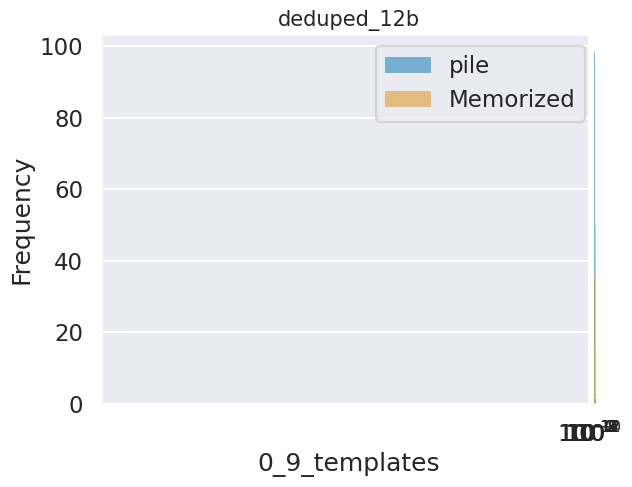

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os 
import pandas as pd 
import random 

#splits = ['.deduped.1.4b', '.deduped.12b', '.deduped.160m', '.deduped.1b', '.deduped.2.8b', '.deduped.410m', '.deduped.6.9b', '.deduped.70m', '.duped.1.4b', '.duped.12b', '.duped.160m', '.duped.1b', '.duped.2.8b', '.duped.410m', '.duped.6.9b', '.duped.70m']
splits = ['_deduped_12b']


#features = [
    #'sequence_duplicates', 'max_frequency', 'avg_frequency', 'min_frequency',
    #'median_frequency', 'p25_frequency', 'p75_frequency',
    #'templating_frequency_0.9', 'templating_frequency_0.8', 'prompt_perplexity', 'generation_perplexity', 'sequence_perplexity'
#]

features = ['0_9_templates']

e = 1e-10 
sns.set_theme(style="darkgrid")
sns.set_palette("colorblind")
sns.set_context("talk")


for split in splits:
    for fx in features:
        mem = dataset['memories' + split][fx] 
        mem = [value for value in mem if value >= 0]
        #mem = mem[:1000]
        df_mem = pd.DataFrame(mem, columns=[fx])
         
        ppile = dataset['pile' + split][fx] 
        ppile = [value for value in ppile if value >= 0]
        #ppile = ppile[:1000]
        df_pile = pd.DataFrame(ppile, columns=[fx])

        #print(f'memorized min: {np.log10(df_mem[fx].min())}, memorized max: {np.log10(df_mem[fx].max())}, pile min: {np.log10(df_pile[fx].min())}, pile max:{np.log10(df_pile[fx].max())}')
        #print(f'memorized min:{min(mem)}, memoirzed max:{max(mem)}, pile min:{min(ppile)}, pile max:{max(ppile)}')
        
        bins = np.logspace(np.log10(min(df_mem[fx].min(), df_pile[fx].min())+e) , np.log10(max(df_mem[fx].max(), df_pile[fx].max())), 10)
        #bins = 50
        sns.histplot(data=df_pile[fx], bins=bins, label="pile", alpha=0.5, stat='percent') 
        sns.histplot(data=df_mem[fx], bins=bins, label="Memorized", alpha=0.5, stat='percent')
       
        plt.xlim(min(df_mem[fx].min(), df_pile[fx].min()), max(df_mem[fx].max(), df_pile[fx].max()))
        plt.xscale('log')
        #plt.yscale('log')
        #plt.xticks([np.ceil(min(df_mem[fx])), np.ceil(max(df_mem[fx])), np.ceil((min(df_mem[fx])+max(df_mem[fx]))/2)])

        plt.xlabel(fx)
        plt.ylabel('Frequency')
        plt.title(split[1:].replace('.', ' ', 1), fontsize=15)
        plt.legend()
        plt.show() 

In [4]:
import pandas as pd
import numpy as np

splits = ['_deduped_12b']

features = ['0_9_templates']
e=1e-10 

for split in splits:
    for fx in features:
        mem = dataset['memories' + split][fx] 
        mem = [value for value in mem if value >= 0]
        #mem = mem[:100000]
        df_mem = pd.DataFrame(mem, columns=[fx])
         
        ppile = dataset['pile' + split][fx] 
        ppile = [value for value in ppile if value >= 0]
        #ppile = ppile[:100000]
        df_pile = pd.DataFrame(ppile, columns=[fx])

        #print(f'memorized min: {np.log10(df_mem[fx].min()+e)}, memorized max: {np.log10(df_mem[fx].max())}, pile min: {np.log10(df_pile[fx].min()+e)}, pile max:{np.log10(df_pile[fx].max())}, samples:{len(mem)}')
        print(f'memorized min:{min(mem)}, memoirzed max:{max(mem)}, pile min:{min(ppile)}, pile max:{max(ppile)}, samples:{len(mem)}')
         

memorized min:0, memoirzed max:1239, pile min:1, pile max:1239, samples:1871216


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

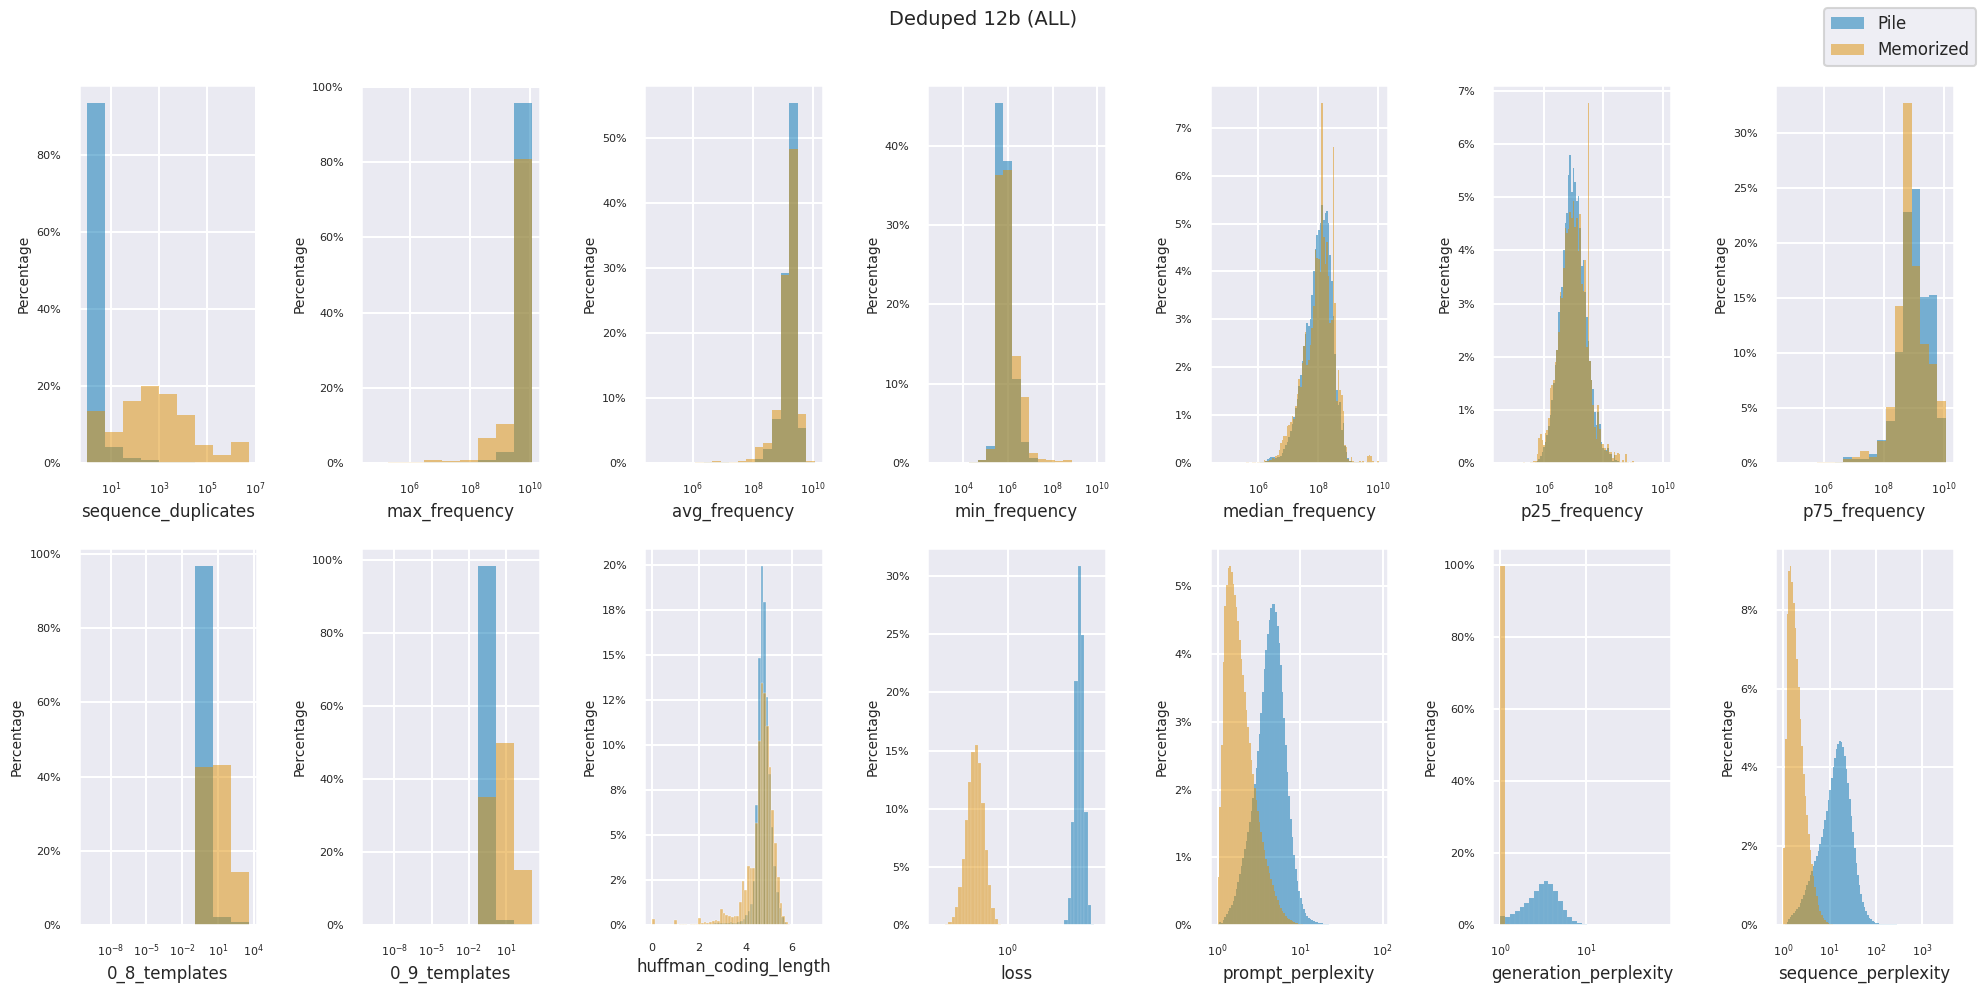

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

splits = ['_deduped_12b']
#splits = ['.deduped.1.4b', '.deduped.12b', '.deduped.160m', '.deduped.1b', '.deduped.2.8b', '.deduped.410m', '.deduped.6.9b', '.deduped.70m', '.duped.1.4b', '.duped.12b', '.duped.160m', '.duped.1b', '.duped.2.8b', '.duped.410m', '.duped.6.9b', '.duped.70m']
 
features = [
    'sequence_duplicates', 'max_frequency', 'avg_frequency', 'min_frequency',
    'median_frequency', 'p25_frequency', 'p75_frequency',
    '0_8_templates', '0_9_templates', 'huffman_coding_length', 'loss', 'prompt_perplexity', 'generation_perplexity', 'sequence_perplexity'
]

e = 1e-10
sns.set_theme(style="darkgrid")
sns.set_palette("colorblind")
sns.set_context("talk")

num_rows = 2
num_columns = 7 
fig, axs = plt.subplots(num_rows, num_columns, figsize=(20, 10))
axs = axs.flatten()

for i, split in tqdm(enumerate(splits), total=len(splits)):
    for j, fx in tqdm(enumerate(features), total=len(features)):
        mem = dataset['memories' + split][fx]
        mem = [value for value in mem if value >= 0]
        #mem = mem[:1000]
        df_mem = pd.DataFrame(mem, columns=[fx])

        ppile = dataset['pile' + split][fx]
        ppile = [value for value in ppile if value >= 0]
        #ppile = ppile[:1000]
        df_pile = pd.DataFrame(ppile, columns=[fx])

        bins_per_feature = {
        'sequence_duplicates': 10,
        'max_frequency': 10,
        'avg_frequency': 20,
        'min_frequency': 20,
        'median_frequency': 100,
        'p25_frequency': 100,
        'p75_frequency': 20,
        '0_8_templates': 10,
        '0_9_templates': 10,
        'prompt_perplexity': 100,
        'generation_perplexity': 35,
        'sequence_perplexity': 100, 
        'huffman_coding_length': 60, #dont take log scale for this feature 
        #'0_8_snowclones': 40, 
        #'0_9_snowclones': 40, 
        'loss': 50 
          }


    
        bins_all = np.logspace(np.log10(min(df_mem[fx].min(), df_pile[fx].min())+e), np.log10(max(df_mem[fx].max(), df_pile[fx].max())), bins_per_feature[fx])
        if fx == 'huffman_coding_length':
            bins = 60 
        else: 
            bins = bins_all  

        sns.histplot(data=df_pile[fx], bins=bins, label="Pile", ax=axs[i * num_columns + j], alpha=0.5, stat="percent")
        sns.histplot(data=df_mem[fx], bins=bins, label="Memorized", ax=axs[i * num_columns + j], alpha=0.5, stat="percent") 

        if fx == 'huffman_coding_length':
            axs[i * num_columns + j].set_xscale('linear') 
            axs[i * num_columns + j].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        else:
            axs[i * num_columns + j].set_xscale('log')   
            axs[i * num_columns + j].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
         
        #axs[j].set_yscale('log')   

        #axs[i * num_columns + j].set_xlim(min(df_mem[fx].min(), df_pile[fx].min()), max(df_mem[fx].max(), df_pile[fx].max()))
        axs[i * num_columns + j].tick_params(axis='both', labelsize=8) 

        axs[i * num_columns + j].set_xlabel(fx, fontsize=12)
        axs[i * num_columns + j].set_ylabel('Percentage', fontsize=10)
        #axs[i * num_columns + j].set_title(split[1:].replace('.', ' ', 1), fontsize=15)

#plt.suptitle(split[1:].replace('.', ' ', 1), y=1.0, fontsize=14)
plt.suptitle('Deduped 12b (ALL)', y=1.0, fontsize=14)
fig.legend(labels=["Pile", "Memorized"], loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

0it [00:00, ?it/s]

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f6b68d1c860> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

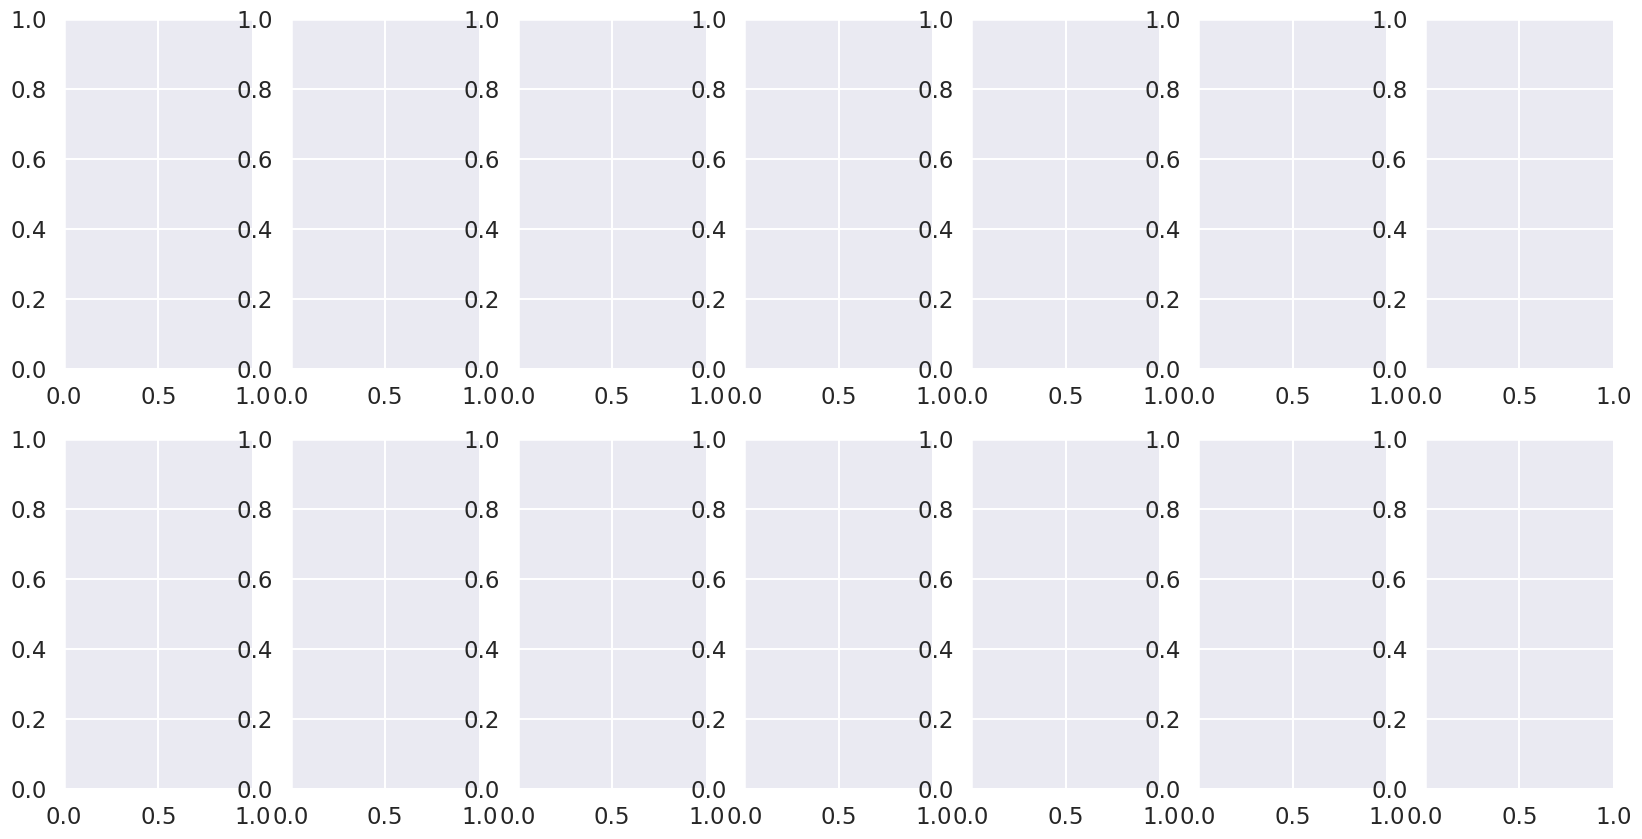

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from matplotlib.ticker import PercentFormatter

splits = ['_deduped_12b']
#splits = ['.deduped.1.4b', '.deduped.12b', '.deduped.160m', '.deduped.1b', '.deduped.2.8b', '.deduped.410m', '.deduped.6.9b', '.deduped.70m', '.duped.1.4b', '.duped.12b', '.duped.160m', '.duped.1b', '.duped.2.8b', '.duped.410m', '.duped.6.9b', '.duped.70m']
 
features = [
    'sequence_duplicates', 'max_frequency', 'avg_frequency', 'min_frequency',
    'median_frequency', 'p25_frequency', 'p75_frequency',
    '0_8_templates', '0_9_templates', 'huffman_coding_length', 'loss', 'prompt_perplexity', 'generation_perplexity', 'sequence_perplexity'
]

e = 1e-10
sns.set_theme(style="darkgrid")
sns.set_palette("colorblind")
sns.set_context("talk")

num_rows = 2
num_columns = 7 
fig, axs = plt.subplots(num_rows, num_columns, figsize=(20, 10))
axs = axs.flatten()

for i, split in tqdm(enumerate(splits)):
    for j, fx in enumerate(features):
        mem = dataset['memories_deduped_12b'].select_columns([fx, 'nl_scores'])
        #mem = [value for value in mem if value >= 0]
        #mem = mem[:1000]
        df_mem = pd.DataFrame(mem, columns=[fx, 'nl_scores'])
        df_mem_nl = df_mem[df_mem['nl_scores'] > 0.457414]
        df_mem_nl = df_mem_nl.copy()
        df_mem_nl.drop(columns=['nl_scores'], inplace=True)

        ppile = dataset['pile_deduped_12b'].select_columns([fx, 'nl_scores'])
        #ppile = [value for value in ppile if value >= 0]
        #ppile = ppile[:1000]
        df_pile = pd.DataFrame(ppile, columns=[fx, 'nl_scores'])
        df_pile_nl = df_pile[df_pile['nl_scores'] > 0.457414]
        df_pile_nl = df_pile_nl.copy()
        df_pile_nl.drop(columns=['nl_scores'], inplace=True)


        bins_per_feature = {
        'sequence_duplicates': 10,
        'max_frequency': 10,
        'avg_frequency': 20,
        'min_frequency': 20,
        'median_frequency': 100,
        'p25_frequency': 100,
        'p75_frequency': 20,
        '0_8_templates': 10,
        '0_9_templates': 10,
        'prompt_perplexity': 100,
        'generation_perplexity': 35,
        'sequence_perplexity': 100, 
        'huffman_coding_length': 60, #dont take log scale for this feature 
        #'0_8_snowclones': 40, 
        #'0_9_snowclones': 40, 
        'loss': 50 
          }


    
        bins_all = np.logspace(np.log10(min(df_mem_nl[fx].min(), df_pile_nl[fx].min())+e), np.log10(max(df_mem_nl[fx].max(), df_pile_nl[fx].max())), bins_per_feature[fx])
        if fx == 'huffman_coding_length':
            bins = 60 
        else: 
            bins = bins_all  

        sns.histplot(data=df_pile_nl[fx], bins=bins, label="Pile", ax=axs[i * num_columns + j], alpha=0.5, stat="percent")
        sns.histplot(data=df_mem_nl[fx], bins=bins, label="Memorized", ax=axs[i * num_columns + j], alpha=0.5, stat="percent") 

        if fx == 'huffman_coding_length':
            axs[i * num_columns + j].set_xscale('linear') 
            axs[i * num_columns + j].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        else:
            axs[i * num_columns + j].set_xscale('log')   
            axs[i * num_columns + j].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
         
        #axs[j].set_yscale('log')   

        #axs[i * num_columns + j].set_xlim(min(df_mem[fx].min(), df_pile[fx].min()), max(df_mem[fx].max(), df_pile[fx].max()))
        axs[i * num_columns + j].tick_params(axis='both', labelsize=8) 

        axs[i * num_columns + j].set_xlabel(fx, fontsize=12)
        axs[i * num_columns + j].set_ylabel('Percentage', fontsize=10)
        #axs[i * num_columns + j].set_title(split[1:].replace('.', ' ', 1), fontsize=15)

#plt.suptitle(split[1:].replace('.', ' ', 1), y=1.0, fontsize=14)
plt.suptitle('Deduped 12b (NL only)', y=1.0, fontsize=14)
fig.legend(labels=["Pile", "Memorized"], loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

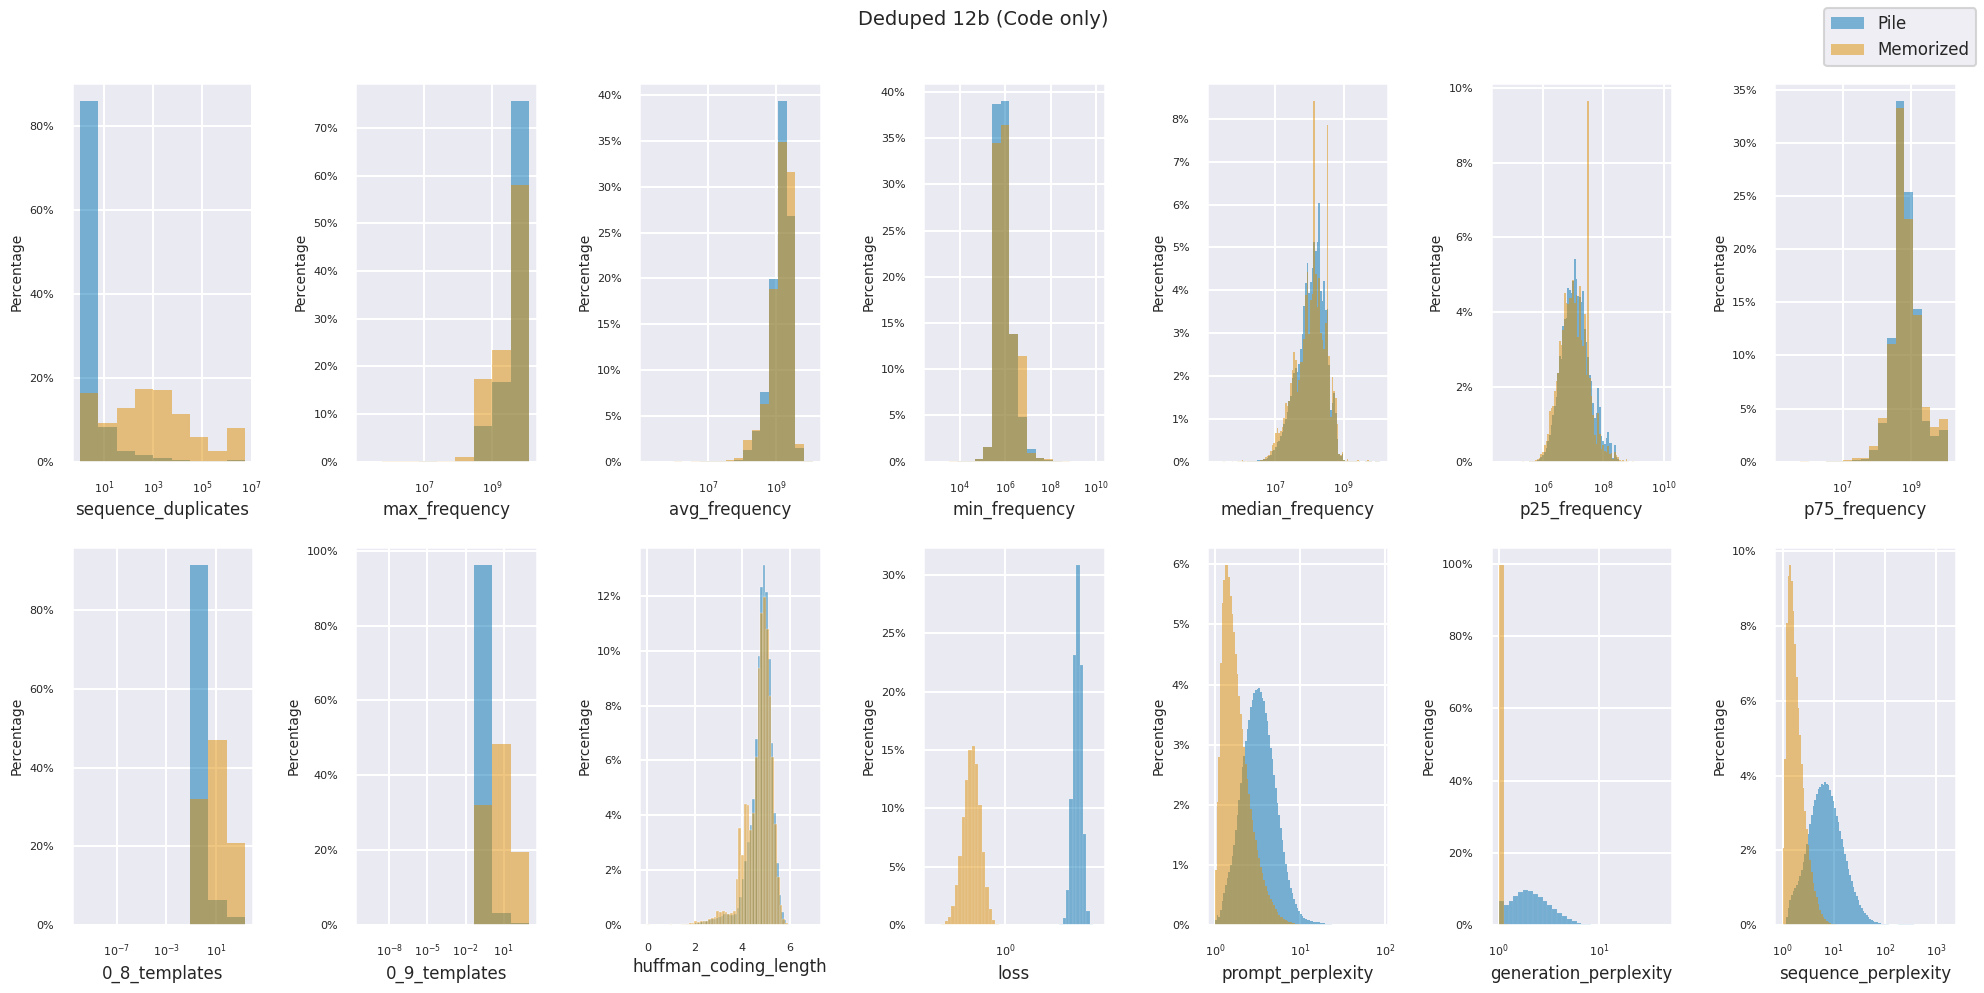

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

splits = ['_deduped_12b']
#splits = ['.deduped.1.4b', '.deduped.12b', '.deduped.160m', '.deduped.1b', '.deduped.2.8b', '.deduped.410m', '.deduped.6.9b', '.deduped.70m', '.duped.1.4b', '.duped.12b', '.duped.160m', '.duped.1b', '.duped.2.8b', '.duped.410m', '.duped.6.9b', '.duped.70m']
 
features = [
    'sequence_duplicates', 'max_frequency', 'avg_frequency', 'min_frequency',
    'median_frequency', 'p25_frequency', 'p75_frequency',
    '0_8_templates', '0_9_templates', 'huffman_coding_length', 'loss', 'prompt_perplexity', 'generation_perplexity', 'sequence_perplexity'
]

e = 1e-10
sns.set_theme(style="darkgrid")
sns.set_palette("colorblind")
sns.set_context("talk")

num_rows = 2
num_columns = 7 
fig, axs = plt.subplots(num_rows, num_columns, figsize=(20, 10))
axs = axs.flatten()

for i, split in enumerate(splits):
    for j, fx in enumerate(features):
        mem = dataset['memories_deduped_12b'].select_columns([fx, 'nl_scores'])
        #mem = [value for value in mem if value >= 0]
        #mem = mem[:1000]
        df_mem = pd.DataFrame(mem, columns=[fx, 'nl_scores'])
        df_mem_code = df_mem[df_mem['nl_scores'] <= 0.457414]
        df_mem_code = df_mem_code.copy()
        df_mem_code.drop(columns=['nl_scores'], inplace=True)

        ppile = dataset['pile_deduped_12b'].select_columns([fx, 'nl_scores'])
        #ppile = [value for value in ppile if value >= 0]
        #ppile = ppile[:1000]
        df_pile = pd.DataFrame(ppile, columns=[fx, 'nl_scores'])
        df_pile_code = df_pile[df_pile['nl_scores'] <= 0.457414]
        df_pile_code = df_pile_code.copy()
        df_pile_code.drop(columns=['nl_scores'], inplace=True)


        bins_per_feature = {
        'sequence_duplicates': 10,
        'max_frequency': 10,
        'avg_frequency': 20,
        'min_frequency': 20,
        'median_frequency': 100,
        'p25_frequency': 100,
        'p75_frequency': 20,
        '0_8_templates': 10,
        '0_9_templates': 10,
        'prompt_perplexity': 100,
        'generation_perplexity': 35,
        'sequence_perplexity': 100, 
        'huffman_coding_length': 60, #dont take log scale for this feature 
        #'0_8_snowclones': 40, 
        #'0_9_snowclones': 40, 
        'loss': 50 
          }


    
        bins_all = np.logspace(np.log10(min(df_mem_code[fx].min(), df_pile_code[fx].min())+e), np.log10(max(df_mem_code[fx].max(), df_pile_code[fx].max())), bins_per_feature[fx])
        if fx == 'huffman_coding_length':
            bins = 60 
        else: 
            bins = bins_all  

        sns.histplot(data=df_pile_code[fx], bins=bins, label="Pile", ax=axs[i * num_columns + j], alpha=0.5, stat="percent")
        sns.histplot(data=df_mem_code[fx], bins=bins, label="Memorized", ax=axs[i * num_columns + j], alpha=0.5, stat="percent") 

        if fx == 'huffman_coding_length':
            axs[i * num_columns + j].set_xscale('linear') 
            axs[i * num_columns + j].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        else:
            axs[i * num_columns + j].set_xscale('log')   
            axs[i * num_columns + j].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
         
        #axs[j].set_yscale('log')   

        #axs[i * num_columns + j].set_xlim(min(df_mem[fx].min(), df_pile[fx].min()), max(df_mem[fx].max(), df_pile[fx].max()))
        axs[i * num_columns + j].tick_params(axis='both', labelsize=8) 

        axs[i * num_columns + j].set_xlabel(fx, fontsize=12)
        axs[i * num_columns + j].set_ylabel('Percentage', fontsize=10)
        #axs[i * num_columns + j].set_title(split[1:].replace('.', ' ', 1), fontsize=15)

#plt.suptitle(split[1:].replace('.', ' ', 1), y=1.0, fontsize=14)
plt.suptitle('Deduped 12b (Code only)', y=1.0, fontsize=14)
fig.legend(labels=["Pile", "Memorized"], loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()